### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.26421983, 0.37098368, 0.19452655, 0.60199529, 0.57735679,
       0.08191166, 0.29748814, 0.46178772, 0.11163955, 0.69341367,
       0.14403409, 0.34750332, 0.0351718 , 0.90971335, 0.78844201,
       0.61493495, 0.57700396, 0.49801161, 0.82563957, 0.45444366])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 1e-02 #  for PD controller   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.81325671,  0.        ,  0.56171096],
        [ 0.        ,  1.        , -0.26115625],
        [-0.58190508,  0.        ,  0.78503389]],

       [[ 0.7808955 ,  0.        ,  0.58216669],
        [ 0.        ,  1.        , -0.36253237],
        [-0.62466168,  0.        ,  0.7277721 ]],

       [[ 0.96573819,  0.        ,  0.25462362],
        [ 0.        ,  1.        , -0.19330204],
        [-0.25951832,  0.        ,  0.94752369]],

       [[ 0.9198599 ,  0.        ,  0.32329291],
        [ 0.        ,  1.        , -0.56628813],
        [-0.39224706,  0.        ,  0.75815529]],

       [[ 0.56366812,  0.        ,  0.69211337],
        [ 0.        ,  1.        , -0.54581108],
        [-0.82600136,  0.        ,  0.47230218]],

       [[ 0.94113253,  0.        ,  0.33690439],
        [ 0.        ,  1.        , -0.08182009],
        [-0.3380378 ,  0.        ,  0.93797703]],

       [[ 0.99549606,  0.        ,  0.09063882],
        [ 0.        ,  1.        , -0.2931196 ],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.57738716,  0.        ,  0.74735666],
        [ 0.        ,  0.        , -0.2006091 ],
        [-0.80694256,  0.        , -0.60148837]],

       [[-0.27626442,  0.        ,  0.24845763],
        [ 0.        ,  0.        , -0.30210512],
        [-0.34536077,  0.        , -0.34923933]],

       [[-0.15223094,  0.        ,  0.55205648],
        [ 0.        ,  0.        , -0.07337735],
        [-0.5664927 ,  0.        , -0.1633211 ]],

       [[-0.01746441,  0.        , -0.08173817],
        [ 0.        ,  0.        , -0.42854833],
        [-0.04095585,  0.        , -0.28524032]],

       [[-0.58011988,  0.        ,  0.05300338],
        [ 0.        ,  0.        , -0.51798682],
        [-0.39587717,  0.        , -0.67627741]],

       [[-0.10437284,  0.        ,  0.2755525 ],
        [ 0.        ,  0.        , -0.50657343],
        [-0.29058489,  0.        , -0.14316207]],

       [[-0.07431384,  0.        ,  0.7249832 ],
        [ 0.        ,  0.        , -0.72550114],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.37039763,  0.89860576,  0.16051956],
       [ 0.4817973 ,  0.29986637,  0.08336704],
       [ 0.21140413,  0.48093045,  0.49851253],
       [ 0.50022088,  0.00609719, -0.15250327],
       [ 0.41678195,  0.64843886, -0.46399884],
       [ 0.72538945,  0.24876683,  0.51594818],
       [ 0.79081741,  0.66938626,  0.29981504],
       [ 0.8268762 ,  0.46715761,  0.01640322],
       [ 0.77479418,  0.81080799, -0.65366325],
       [ 0.77681072,  0.03420296,  0.05833871],
       [ 0.49849409,  0.0621833 ,  0.67129457],
       [ 0.516771  , -0.12052644,  0.35150428],
       [ 0.53325922,  0.54826841,  0.52617064],
       [ 0.19580747,  0.54151812,  0.30413904],
       [ 0.50748258,  0.60897124, -0.16133992],
       [ 0.679867  ,  0.55959261,  0.30353885],
       [ 0.1113521 , -0.05978355,  0.07507083],
       [ 0.9944155 ,  0.46123924,  0.32243612],
       [ 0.38548881,  0.07326225, -0.08311265],
       [ 0.32988352,  0.58988197,  0.29397035]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.97152838,  0.61425855, -0.34181603],
       [ 0.85476192,  0.29885644, -0.36357752],
       [ 1.07252173,  0.36500934, -0.22782442],
       [ 0.13567652,  0.70372256,  0.08124835],
       [ 0.28277641,  0.64391318, -1.07593768],
       [ 1.06703772, -0.32827336,  0.04960509],
       [ 0.93541331, -0.179947  , -0.43547949],
       [ 1.06201737, -0.06838835, -0.4178149 ],
       [ 0.07405305,  0.23148282, -0.28894249],
       [ 0.49773526,  0.38015627, -0.34822561],
       [ 1.31501952,  0.64829799,  0.42539219],
       [ 0.23389008,  0.49097508,  0.67313347],
       [ 1.1703194 ,  0.24753712,  0.21922237],
       [ 0.9028627 , -0.64401733,  0.27059916],
       [ 0.06591758,  0.7400714 , -0.54881619],
       [ 1.14990039, -0.16836574, -0.44939334],
       [ 0.25261601,  0.49253474,  0.14836709],
       [ 0.40037806,  0.14357916, -1.04012494],
       [ 0.89661649, -0.10714575, -0.2617446 ],
       [ 0.4243767 , -0.14595777,  0.22200356]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.46750362, 0.68180832, 0.34776451],
       [0.93646458, 0.81594706, 0.78268717],
       [0.99712276, 0.27703184, 0.4843835 ],
       [0.47278229, 0.06915226, 0.10967746],
       [0.41876845, 0.52436458, 0.41289048],
       [0.12120007, 0.29810419, 0.6335216 ],
       [0.18077802, 0.0819649 , 0.572859  ],
       [0.33749089, 0.93942859, 0.83091451],
       [0.9896902 , 0.12606851, 0.52072169],
       [0.89912089, 0.74821843, 0.84281225],
       [0.17335922, 0.77261271, 0.38125553],
       [0.00947963, 0.4188681 , 0.02277385],
       [0.96460139, 0.77406411, 0.48246883],
       [0.29345684, 0.7842813 , 0.95432145],
       [0.29363162, 0.98084845, 0.75606679],
       [0.67819017, 0.36398971, 0.99491676],
       [0.693981  , 0.93014269, 0.3408462 ],
       [0.65601575, 0.19195054, 0.81962265],
       [0.08915367, 0.2906575 , 0.53892566],
       [0.20523754, 0.23039343, 0.58860935]])

In [44]:
theta(φ,θ,ψ)

array([[0.26421983, 0.62106927, 0.89176724],
       [0.37098368, 0.67469821, 0.83752779],
       [0.19452655, 0.2625234 , 0.19335078],
       [0.60199529, 0.40307315, 0.71791471],
       [0.57735679, 0.9719764 , 0.27346774],
       [0.08191166, 0.34483118, 0.06136692],
       [0.29748814, 0.09494555, 0.0865834 ],
       [0.46178772, 0.31278289, 0.87806406],
       [0.11163955, 0.9457333 , 0.5231653 ],
       [0.69341367, 0.48103988, 0.88149988],
       [0.14403409, 0.40954435, 0.16754622],
       [0.34750332, 0.20456043, 0.8357763 ],
       [0.0351718 , 0.67726646, 0.400142  ],
       [0.90971335, 0.00178408, 0.32371473],
       [0.78844201, 0.58101893, 0.27532179],
       [0.61493495, 0.26903469, 0.96652345],
       [0.57700396, 0.51674451, 0.46063535],
       [0.49801161, 0.38245864, 0.90841764],
       [0.82563957, 0.70286548, 0.63443538],
       [0.45444366, 0.21780168, 0.07145578]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.55862963,  0.52508505, -0.05357737],
       [ 0.97950333,  0.18551767, -0.36427616],
       [ 1.03100352, -0.12980812, -0.01985318],
       [ 0.4783994 ,  0.01920897,  0.06474507],
       [ 0.55136017,  0.3564686 ,  0.11686944],
       [ 0.30056029,  0.22150917,  0.56554027],
       [ 0.22630858, -0.02103226,  0.546831  ],
       [ 0.83209839,  0.6642957 ,  0.19035019],
       [ 1.01777715, -0.30917982,  0.1591425 ],
       [ 1.01578969,  0.08848174, -0.22730963],
       [ 0.38627142,  0.70684911,  0.14791461],
       [ 0.01792243,  0.41865221,  0.01694849],
       [ 0.88191975,  0.37756066, -0.47773904],
       [ 0.85297403,  0.5082314 ,  0.43940654],
       [ 0.76473058,  0.7620198 ,  0.15861174],
       [ 0.90957335, -0.26020587,  0.48255307],
       [ 0.62486121,  0.71213662, -0.39975941],
       [ 0.76787363, -0.30799015,  0.51241325],
       [ 0.23924729,  0.24267392,  0.48872032],
       [ 0.33140862,  0.11043501,  0.51416118]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.62901494, -0.53742069,  0.56171096],
        [ 0.75117722,  0.60624269, -0.26115625],
        [-0.20018239,  0.58621566,  0.78503389]],

       [[ 0.69091243, -0.42862801,  0.58216669],
        [ 0.69244596,  0.62376989, -0.36253237],
        [-0.20774652,  0.65359709,  0.7277721 ]],

       [[ 0.95738172, -0.13633433,  0.25462362],
        [ 0.18852426,  0.96285665, -0.19330204],
        [-0.21881234,  0.23306657,  0.94752369]],

       [[ 0.83893643, -0.43779831,  0.32329291],
        [ 0.54217637,  0.62077575, -0.56628813],
        [ 0.04722759,  0.65036152,  0.75815529]],

       [[ 0.66448172,  0.28185658,  0.69211337],
        [ 0.22629551,  0.80677172, -0.54581108],
        [-0.71221794,  0.51930363,  0.47230218]],

       [[ 0.94105722, -0.03011194,  0.33690439],
        [ 0.06112278,  0.99477107, -0.08182009],
        [-0.33267898,  0.09758992,  0.93797703]],

       [[ 0.99416995, -0.05840127,  0.09063882],
        [ 0.0826769 ,  0.95249432, -0.2931196 ],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-0.23748847,  0.00647726,  0.30655936],
       [-0.0178271 , -0.25458027,  0.28672818],
       [ 0.07229011,  0.01749524, -0.15881807],
       [-0.02169091,  0.05950275,  0.05598534],
       [ 0.52203259, -0.3581399 , -0.07463215],
       [ 0.20637223, -0.0583155 , -0.012041  ],
       [ 0.03540877, -0.16434787,  0.01234096],
       [-0.6343348 , -0.36160516,  0.66647584],
       [ 0.43517389, -0.0420676 , -0.81691225],
       [-0.27905203, -0.53057567,  0.76872162],
       [ 0.07377031, -0.05911972,  0.08626206],
       [-0.29454674, -0.00475956,  0.21014555],
       [ 0.09580821,  0.14521051, -0.4245227 ],
       [-0.39674697, -0.81064727,  0.7882078 ],
       [ 0.55698602, -0.65827133,  0.63766284],
       [-0.50461786, -0.39327687,  0.48785549],
       [ 0.04343299, -0.20089876,  0.45980517],
       [-0.14863645, -0.25901291,  0.17962598],
       [ 0.18720986, -0.50768495,  0.24283867],
       [ 0.11791911, -0.27662451,  0.06716006]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 0.00686455, -0.49397394,  0.34199314],
       [ 0.05588487, -0.51083987,  0.3867697 ],
       [ 0.00869017, -0.02002439,  0.01844524],
       [-0.12670463, -0.37866104,  0.31884524],
       [ 0.56297914, -0.34152506,  0.02528441],
       [ 0.01055247, -0.00355268,  0.00587784],
       [ 0.00087679, -0.01019576,  0.00816794],
       [-0.2583753 , -0.31842057,  0.24931102],
       [ 0.26218652, -0.23089002,  0.36143451],
       [-0.207388  , -0.62412317,  0.50372532],
       [ 0.02578562, -0.01955221,  0.02562569],
       [-0.2098717 , -0.17494288,  0.13007967],
       [ 0.06924126, -0.10105757,  0.16496035],
       [-0.08248878, -0.11527152,  0.23244788],
       [ 0.26337995, -0.42407165,  0.1406857 ],
       [-0.43967792, -0.40828928,  0.39338652],
       [ 0.09614276, -0.28975757,  0.20462147],
       [-0.25885441, -0.41410801,  0.31625507],
       [ 0.29449553, -0.74572842,  0.44291287],
       [ 0.0210563 , -0.04883467,  0.01493751]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-2.37488467e+08,  6.47726435e+06,  3.06559357e+08],
       [-1.78270993e+07, -2.54580268e+08,  2.86728182e+08],
       [ 7.22901117e+07,  1.74952405e+07, -1.58818074e+08],
       [-2.16909134e+07,  5.95027534e+07,  5.59853421e+07],
       [ 5.22032594e+08, -3.58139895e+08, -7.46321477e+07],
       [ 2.06372231e+08, -5.83154997e+07, -1.20410019e+07],
       [ 3.54087726e+07, -1.64347875e+08,  1.23409598e+07],
       [-6.34334799e+08, -3.61605161e+08,  6.66475837e+08],
       [ 4.35173890e+08, -4.20676015e+07, -8.16912255e+08],
       [-2.79052033e+08, -5.30575666e+08,  7.68721625e+08],
       [ 7.37703077e+07, -5.91197236e+07,  8.62620594e+07],
       [-2.94546743e+08, -4.75956388e+06,  2.10145550e+08],
       [ 9.58082053e+07,  1.45210507e+08, -4.24522695e+08],
       [-3.96746969e+08, -8.10647272e+08,  7.88207795e+08],
       [ 5.56986019e+08, -6.58271327e+08,  6.37662838e+08],
       [-5.04617856e+08, -3.93276868e+08,  4.87855493e+08],
       [ 4.34329925e+07, -2.00898763e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 1.15461169e+08, -3.49177246e+08,  9.68243461e+07],
       [ 2.02573344e+08, -2.29603058e+08, -1.91265164e+08],
       [-3.80796094e+07,  4.72491493e+07, -1.21279898e+07],
       [-1.85308266e+07, -5.06802434e+07,  4.66847817e+07],
       [-1.85939845e+08, -1.43116829e+08, -6.13821455e+08],
       [-2.34968153e+06,  7.34183589e+06, -7.58285610e+07],
       [ 9.76694164e+06, -1.83228157e+06, -5.24243663e+07],
       [ 1.66804109e+08, -8.38365765e+08, -2.96106363e+08],
       [-7.15978126e+08,  4.90774889e+08, -4.06678571e+08],
       [ 8.53120375e+07, -7.91860400e+08, -5.15577225e+08],
       [ 3.88549758e+07, -1.01031688e+07, -4.01525316e+07],
       [-1.34989814e+07, -3.10891117e+08, -2.59619446e+07],
       [-3.23593451e+08,  1.45766428e+08, -2.31697646e+07],
       [-4.01926263e+07, -7.95531626e+08, -8.38410695e+08],
       [ 6.79014920e+07, -6.38864187e+08, -7.18822127e+08],
       [ 9.42547378e+07, -6.93148580e+08, -4.61277329e+08],
       [ 1.32222090e+08, -3.16171755e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 7157939.85138423,  3881786.78877653,  5463166.47628032],
       [ 7772802.64201302,  3710672.80787175,  3777900.69997065],
       [ 2370933.93361771,  2251482.99980511,  1327212.38638468],
       [ 7858480.60670739,   -34734.23215661,  3081599.5444508 ],
       [ 5147083.0035248 ,  8227146.79385457, -3477380.85498173],
       [  977645.12369549,  3398101.29150972,   298715.24681718],
       [ 3039960.85353368,   695662.55773352,   542047.00176993],
       [ 6812691.87441512,  -784379.30825869,  6058572.12649645],
       [ 4869331.26809908,  8874486.07275061,  2136921.65029927],
       [ 9284019.77748368,  -823850.907061  ,  2801546.46680115],
       [ 1981474.4021529 ,  3854953.38558001,   947459.43914533],
       [ 4998866.47293666,  -800643.79442242,  6988437.90406773],
       [ 2780089.45129619,  6631956.44473304,  2895923.24068224],
       [ 9100664.89314549, -2537329.46372262,  1971284.74236382],
       [ 7655921.51339157,  3857453.4826979 , -2705176.03124368],
       [ 8

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[ 4.65661287e-10, -5.09288078e-10, -4.65661287e-10],
       [-2.32830644e-10,  5.25540369e-10,  0.00000000e+00],
       [ 1.16415322e-10,  2.65022686e-11, -1.16415322e-10],
       [ 2.54658516e-11,  9.58591790e-10, -5.45696821e-11],
       [ 0.00000000e+00,  7.97044006e-10,  1.86264515e-09],
       [ 0.00000000e+00, -5.27803297e-12,  5.82076609e-11],
       [ 0.00000000e+00, -6.50647474e-12,  0.00000000e+00],
       [-2.32830644e-10, -1.30628728e-09,  2.32830644e-10],
       [-1.16415322e-09,  3.53809993e-10,  9.31322575e-10],
       [ 4.36557457e-10, -3.98007058e-10, -1.62981451e-09],
       [ 0.00000000e+00,  1.59135815e-11,  0.00000000e+00],
       [ 0.00000000e+00, -2.18035010e-10,  0.00000000e+00],
       [ 0.00000000e+00,  4.66019671e-10, -9.31322575e-10],
       [ 5.82076609e-11, -2.02432729e-10, -4.65661287e-10],
       [-1.16415322e-10,  7.14350680e-11,  0.00000000e+00],
       [ 0.00000000e+00,  1.35080830e-09,  4.65661287e-10],
       [-1.16415322e-10,  3.33664748e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[  7.45791306,  18.69197383,  13.32007942],
       [105.70708517, 377.99274518,  55.75947809],
       [  8.02671577, 253.58567996, 188.55464979],
       [ 45.86501824, 263.11821686, 253.54350859],
       [231.28580008, 252.86917456, 158.96881294],
       [  3.28659333, 173.33494577, 386.67671579],
       [116.47851851, 222.78551495, 113.6985668 ],
       [  8.15061031, 267.52265804,   6.05302493],
       [  2.65186345, 360.9180111 ,  87.23670508],
       [ 74.34020569,  91.96626142,  82.90708939],
       [155.09292183, 153.78569045, 247.58807474],
       [367.34239256,  67.51749939,   1.82174787],
       [  9.7953336 , 339.92699218, 210.4475833 ],
       [ 89.74439847,   8.70157836, 116.13053513],
       [ 63.72438154, 109.19599086,  70.16972481],
       [172.33224884, 205.95882985,  41.07468544],
       [ 29.51676471, 282.33689089, 317.55051415],
       [212.87652635,  17.66646403, 347.01228444],
       [  9.92148394, 240.55055263, 130.22116018],
       [ 74.37857748, 261.77082

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 14269.77234448],
       [ 5845.36330569,  5845.36330569, 24805.54087192],
       [ 5845.36330569,  5845.36330569, 17579.29416609],
       [ 5845.36330569,  5845.36330569,  8502.24097077],
       [ 5845.36330569,  5845.36330569, 15847.41412022],
       [ 5845.36330569,  5845.36330569, 21192.08498295],
       [ 5845.36330569,  5845.36330569, 19722.56584704],
       [ 5845.36330569,  5845.36330569, 25973.82244285],
       [ 5845.36330569,  5845.36330569, 18459.56753003],
       [ 5845.36330569,  5845.36330569, 26262.0388322 ],
       [ 5845.36330569,  5845.36330569, 15081.07428174],
       [ 5845.36330569,  5845.36330569,  6397.04758099],
       [ 5845.36330569,  5845.36330569, 17532.91247518],
       [ 5845.36330569,  5845.36330569, 28963.289495  ],
       [ 5845.36330569,  5845.36330569, 24160.67658784],
       [ 5845.36330569,  5845.36330569, 29946.68904856],
       [ 5845.36330569,  5845.36330569, 14102.17998059],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[  -7.45791306,  -18.69197383, -288.49123109],
       [-105.70708517, -377.99274518, -330.93062977],
       [  -8.02671577, -253.58567996, -463.72580147],
       [ -45.86501824, -263.11821686, -528.71466027],
       [-231.28580008, -252.86917456, -434.13996462],
       [  -3.28659333, -173.33494577, -661.84786747],
       [-116.47851851, -222.78551495, -388.86971847],
       [  -8.15061031, -267.52265804, -281.22417661],
       [  -2.65186345, -360.9180111 , -362.40785676],
       [ -74.34020569,  -91.96626142, -358.07824107],
       [-155.09292183, -153.78569045, -522.75922641],
       [-367.34239256,  -67.51749939, -276.99289955],
       [  -9.7953336 , -339.92699218, -485.61873498],
       [ -89.74439847,   -8.70157836, -391.30168681],
       [ -63.72438154, -109.19599086, -345.34087648],
       [-172.33224884, -205.95882985, -316.24583712],
       [ -29.51676471, -282.33689089, -592.72166583],
       [-212.87652635,  -17.66646403, -622.18343611],
       [  -9.92148394, -240.

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[ 1.31551921e+02, -1.46694329e+01,  4.40962142e+01],
        [-1.46694329e+01,  1.06820259e+02, -2.05016506e+01],
        [ 4.40962142e+01, -2.05016506e+01,  1.61627821e+02]],

       [[ 1.33891805e+02, -2.11054268e+01,  4.23684672e+01],
        [-2.11054268e+01,  1.13142972e+02, -2.63840944e+01],
        [ 4.23684672e+01, -2.63840944e+01,  1.52965223e+02]],

       [[ 1.06483319e+02, -4.92192646e+00,  2.41261912e+01],
        [-4.92192646e+00,  1.03736568e+02, -1.83158258e+01],
        [ 2.41261912e+01, -1.83158258e+01,  1.89780113e+02]],

       [[ 1.10451831e+02, -1.83076937e+01,  2.45106231e+01],
        [-1.83076937e+01,  1.32068224e+02, -4.29334343e+01],
        [ 2.45106231e+01, -4.29334343e+01,  1.57479945e+02]],

       [[ 1.47902092e+02, -3.77763146e+01,  3.26886652e+01],
        [-3.77763146e+01,  1.29790974e+02, -2.57787762e+01],
        [ 3.26886652e+01, -2.57787762e+01,  1.22306935e+02]],

       [[ 1.11350457e+02, -2.75655485e+00,  3.16008582e+01],
        [-2.75

### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

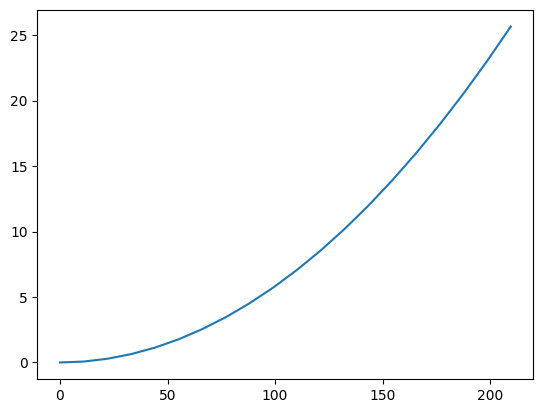

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

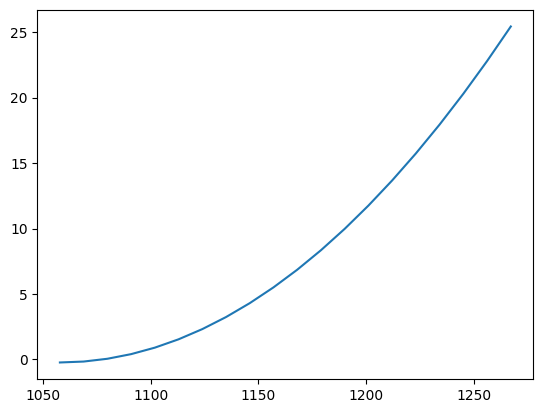

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

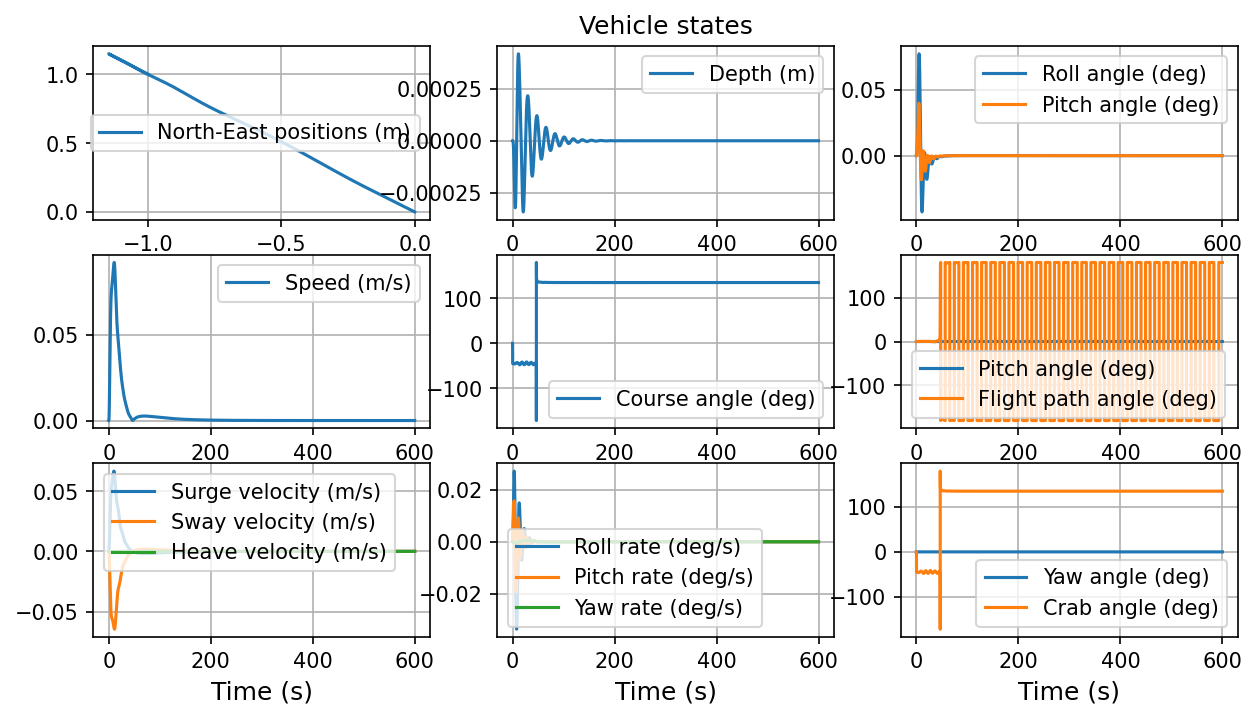

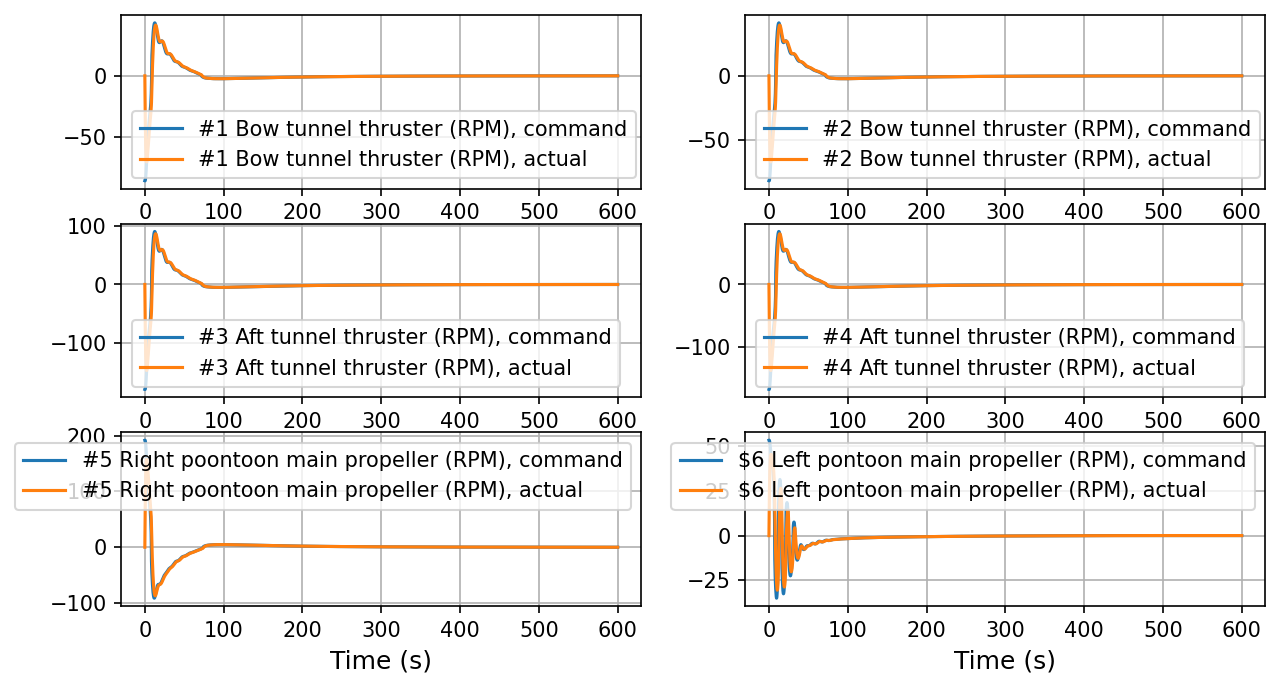

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

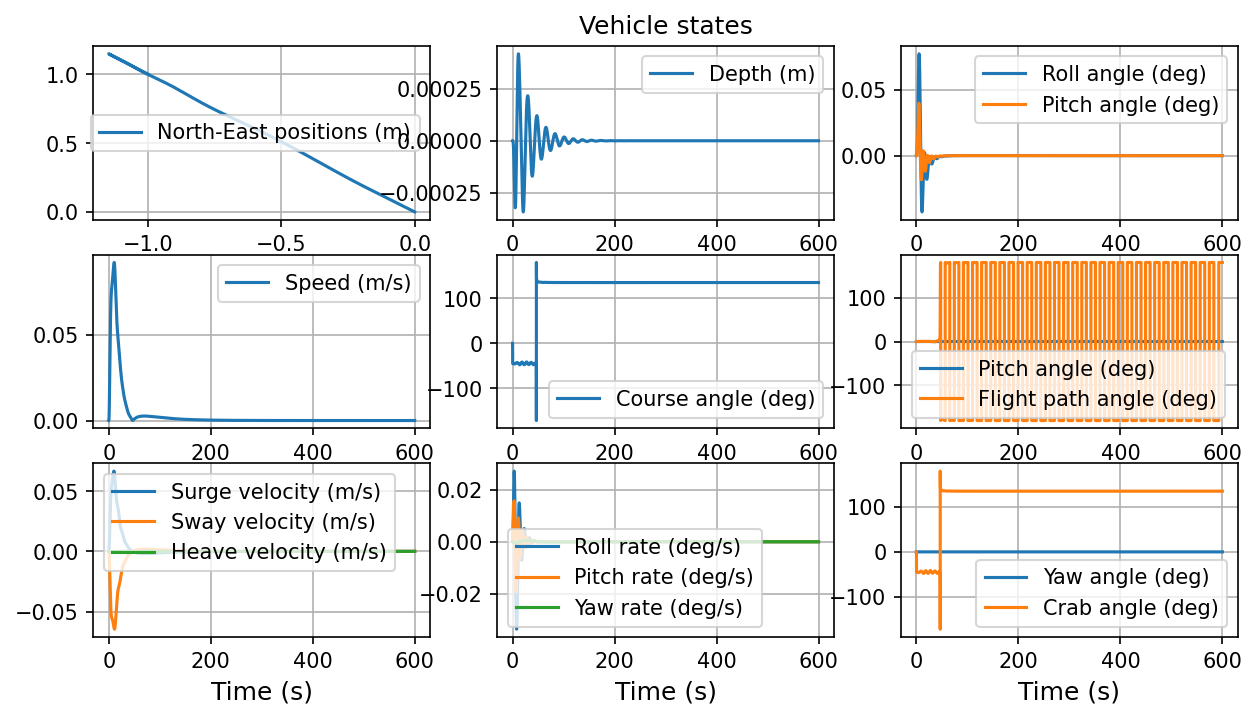

In [95]:
plotVehicleStates(simTime, simData, 3)

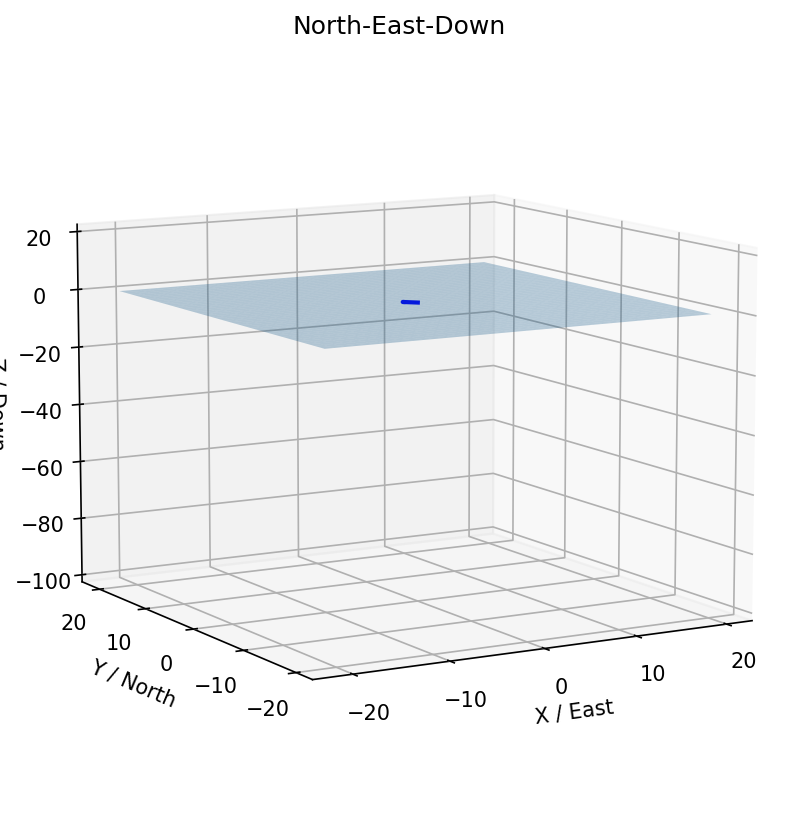

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    

    
    RET = Ret(φ,θ,ψ)
    
    s = np.linspace(0, 1, N)

    x_ref = np.array(x0) + s * (x_ve - x0[-1])
    y_ref = np.zeros(N)  + s * y_ve
    z_ref = np.array(z0) + s * (z_ve - z0[-1])
    φ_ref = np.zeros(N)  + s * phi_ve
    θ_ref = np.zeros(N)  + s * theta_ve
    ψ_ref = np.zeros(N)  + s * psi_ve

    position  = np.sqrt((x - x_ref)**2 + (y - y_ref)**2 + (z - z_ref)**2)
    position_ang = np.sqrt((φ - φ_ref)**2 + (θ - θ_ref)**2 + (ψ - ψ_ref)**2)

    velocity  = np.sqrt(dx**2 + dy**2 + dz**2)
    velocity_ang = np.sqrt(dφ**2 + dθ**2 + dψ**2)     
    
    Z0 = calibr*(np.tile(position, (3, 1)) + np.tile(velocity, (3, 1))).T
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T
    Z = (Z1 + Z2 - Z0 )

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = calibr*(np.tile(position_ang, (3, 1)) + np.tile(velocity_ang, (3, 1))).T
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = (C1 - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001267*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.30483135279049e-08  Iteration wall-clock time:  0:00:00.015414
Physical time:  1.0069806428149786  Iteration wall-clock time:  0:00:00.823273
Physical time:  2.0005325147659008  Iteration wall-clock time:  0:00:01.003917
Physical time:  3.003760663764286  Iteration wall-clock time:  0:00:00.927324
Physical time:  4.010766683580428  Iteration wall-clock time:  0:00:00.963997
Physical time:  5.0211865558678825  Iteration wall-clock time:  0:00:01.017358
Physical time:  6.003373700947495  Iteration wall-clock time:  0:00:01.002734
Physical time:  7.003424470263156  Iteration wall-clock time:  0:00:01.058924
Physical time:  8.0116480382502  Iteration wall-clock time:  0:00:01.204989
Physical time:  9.008431521811682  Iteration wall-clock time:  0:00:01.075709
0:00:10.246770


In [102]:
# max axial tension
T_.top_tension

322410.7928305098

In [103]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.00012530470533803163

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.305e-06 ...  9.996e+00  1.000e+01]
        y: [[ 0.000e+00 -1.143e-20 ...  3.263e-02  3.268e-02]
            [ 1.103e+01  1.103e+01 ...  1.066e+01  1.066e+01]
            ...
            [ 0.000e+00 -4.730e-12 ... -4.651e-06 -4.653e-06]
            [ 0.000e+00 -4.734e-12 ... -4.642e-06 -4.644e-06]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1820
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((224,), (224, 240))

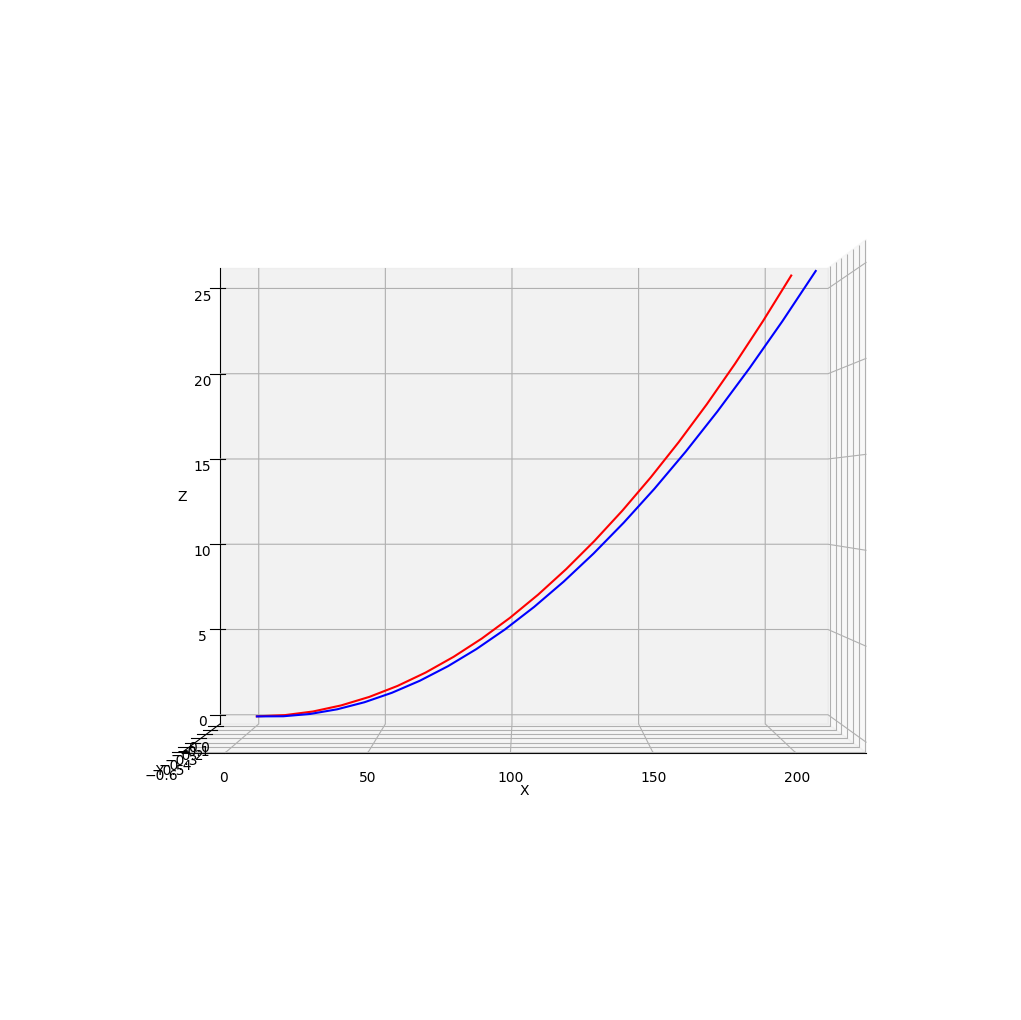

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([3.26812524e-02, 1.06564237e+01, 2.14093369e+01, 3.22200869e+01,
        4.30657225e+01, 5.39363490e+01, 6.48271203e+01, 7.57356922e+01,
        8.66610710e+01, 9.76031653e+01, 1.08562427e+02, 1.19539455e+02,
        1.30534529e+02, 1.41547122e+02, 1.52575003e+02, 1.63614848e+02,
        1.74662821e+02, 1.85715406e+02, 1.96769587e+02, 2.07823299e+02]),
 array([-5.84745832e-05, -1.54888962e-02, -3.60943588e-02, -5.80952915e-02,
        -8.13325276e-02, -1.05768462e-01, -1.31391438e-01, -1.58198883e-01,
        -1.86192652e-01, -2.15377876e-01, -2.45762172e-01, -2.77354505e-01,
        -3.10163648e-01, -3.44196500e-01, -3.79455385e-01, -4.15938950e-01,
        -4.53643307e-01, -4.92564245e-01, -5.32697954e-01, -5.74044510e-01]),
 array([-4.63938006e-03,  3.84633792e-02,  2.17007781e-01,  5.33413768e-01,
         9.88326212e-01,  1.58213533e+00,  2.31515107e+00,  3.18766305e+00,
         4.19996553e+00,  5.35237585e+00,  6.64524151e+00,  8.07893060e+00,
         9.65380205e+00,  1.

In [111]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [112]:
us=fin.T

In [113]:
us.shape

(240, 224)

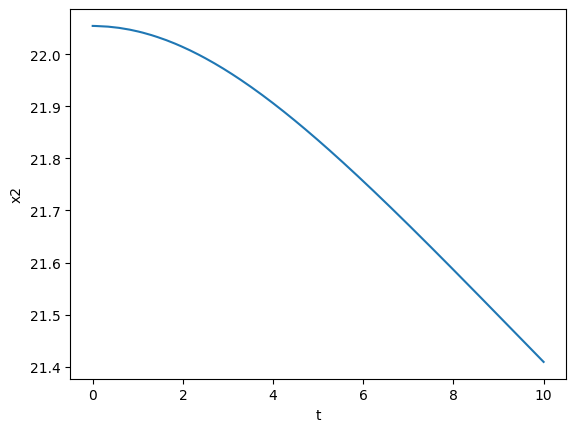

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

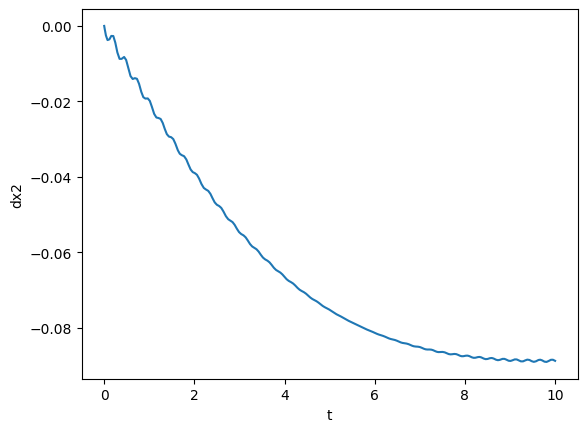

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

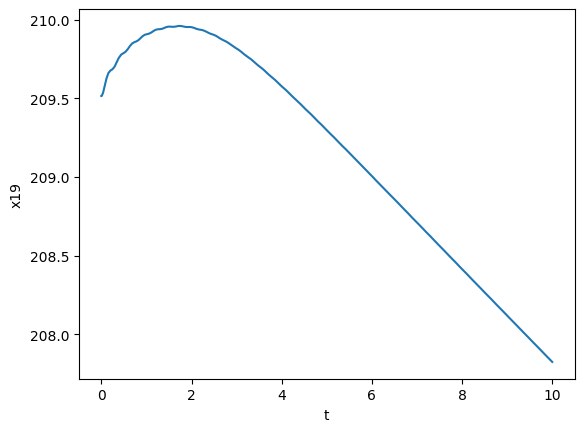

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

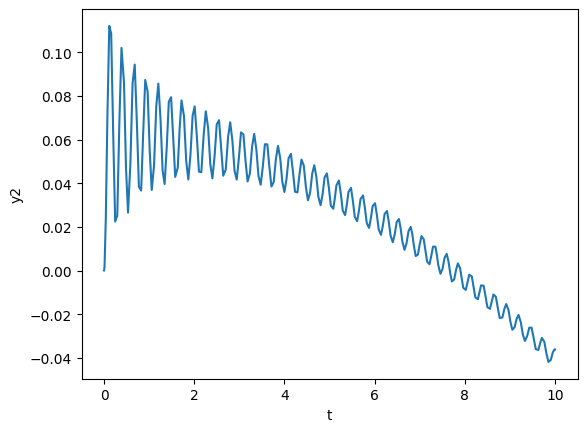

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

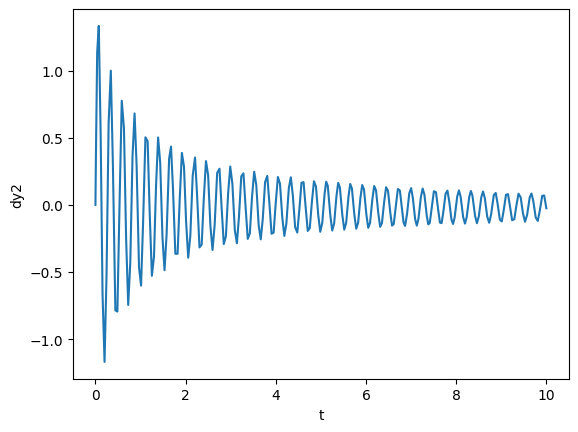

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

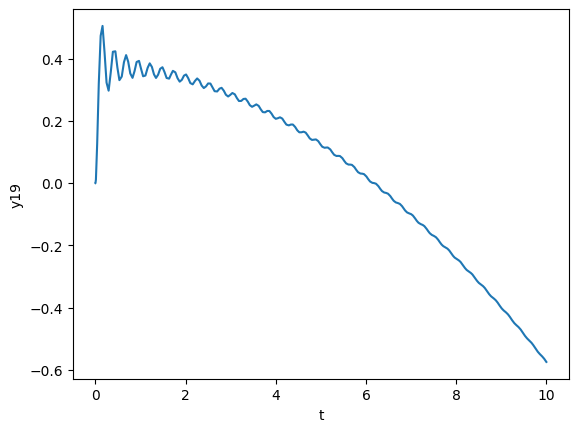

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

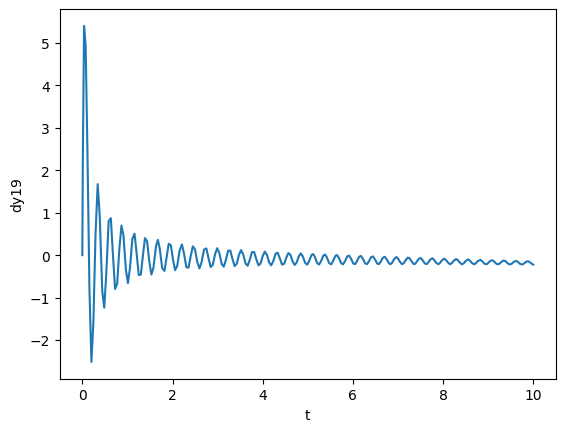

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

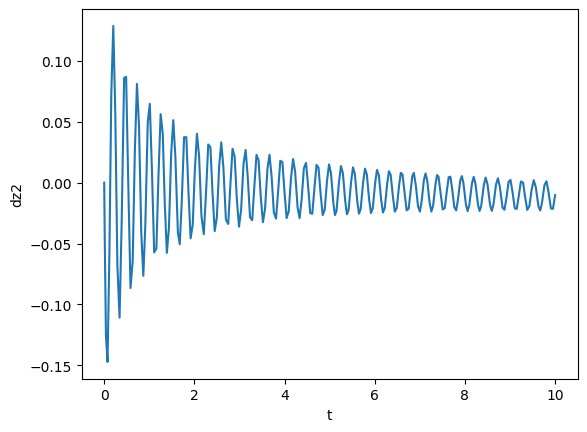

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

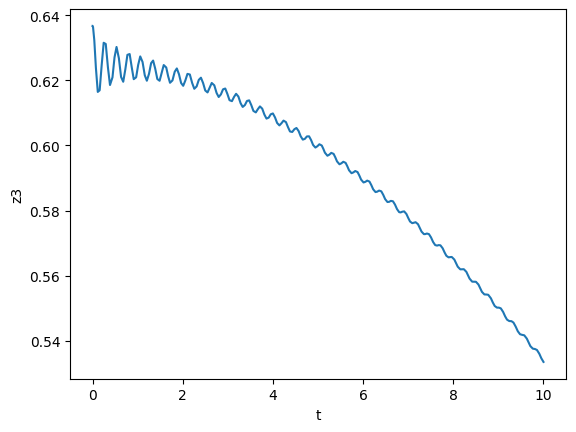

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

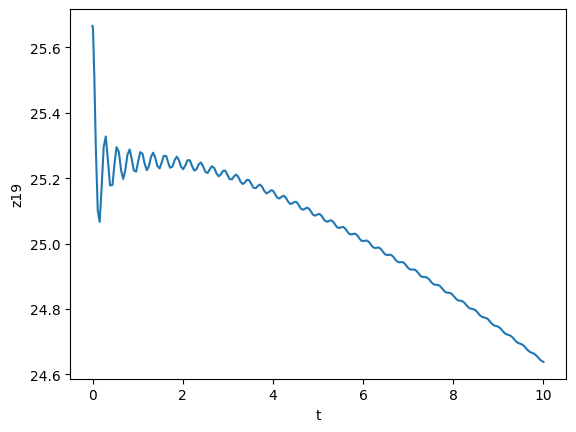

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

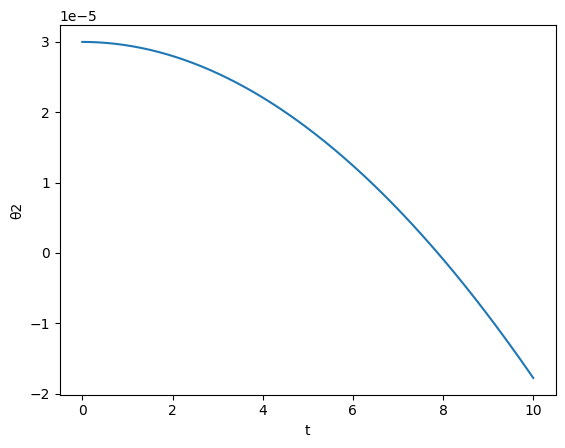

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

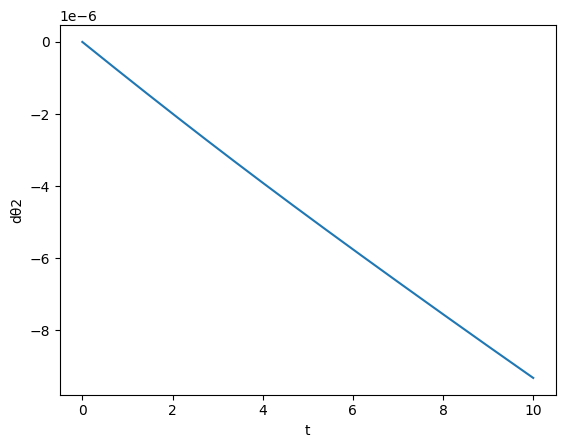

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

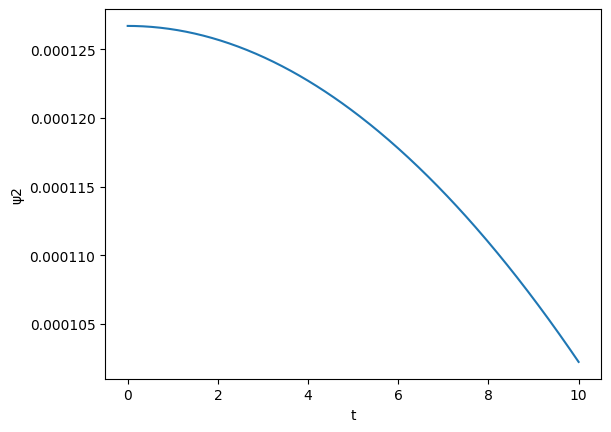

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

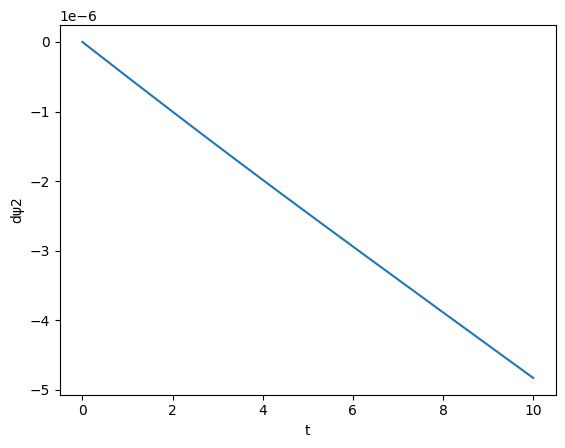

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

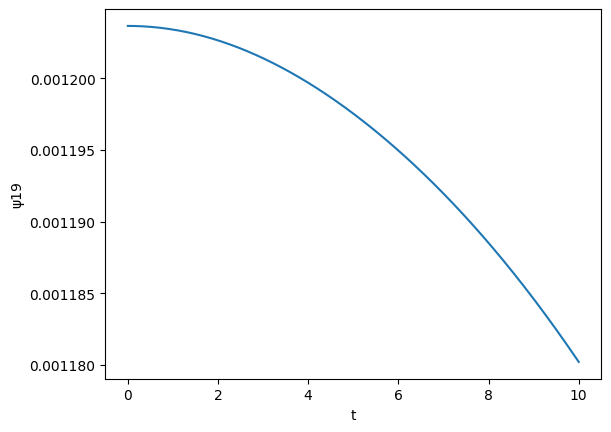

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()